# This is a test

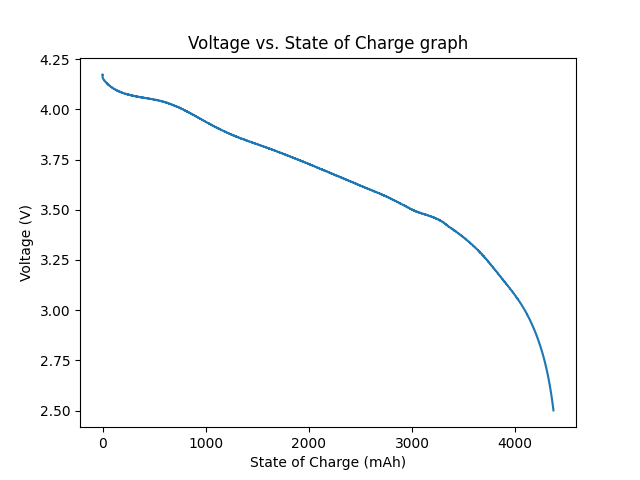

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib ipympl
# read data from the csv file for 1A constant cell run
ocv_data = pd.read_csv("1A Constant Cell 1 Run 1.csv")
ocv_soc = ocv_data["LOAD_CAPACITY"].to_list()
ocv_voltage =  ocv_data["DMM_VOLTAGE"].to_list()

plt.figure()
plt.plot(ocv_soc, ocv_voltage)
plt.title("Voltage vs. State of Charge graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Voltage (V)")
plt.show()

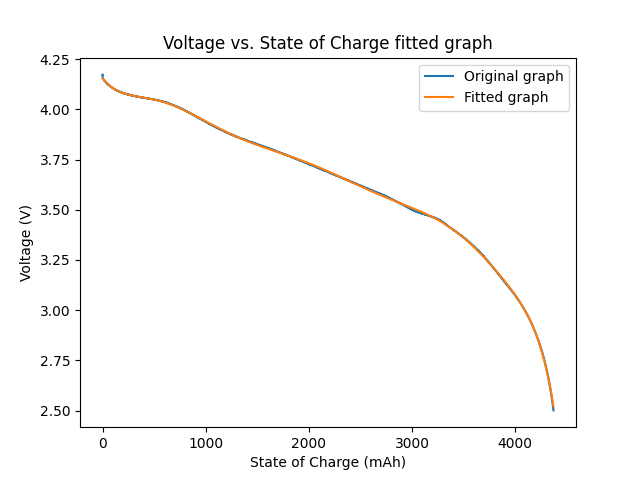

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# find a polynomial fit of the voltage vs. soc graph
ocv_fit = np.polynomial.polynomial.Polynomial.fit(ocv_data["LOAD_CAPACITY"], ocv_data["DMM_VOLTAGE"], 10)

plt.figure()
plt.plot(ocv_soc, ocv_voltage, label="Original graph")
plt.plot(ocv_soc, ocv_fit(ocv_data["LOAD_CAPACITY"]), label="Fitted graph")
plt.legend(loc="upper right")
plt.title("Voltage vs. State of Charge fitted graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Voltage (V)")
plt.show()

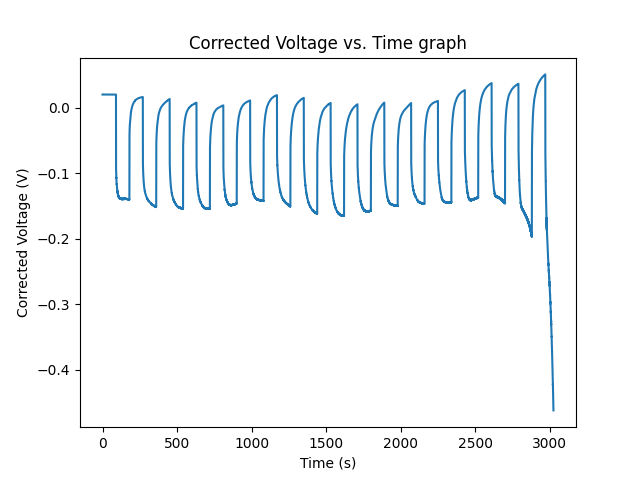

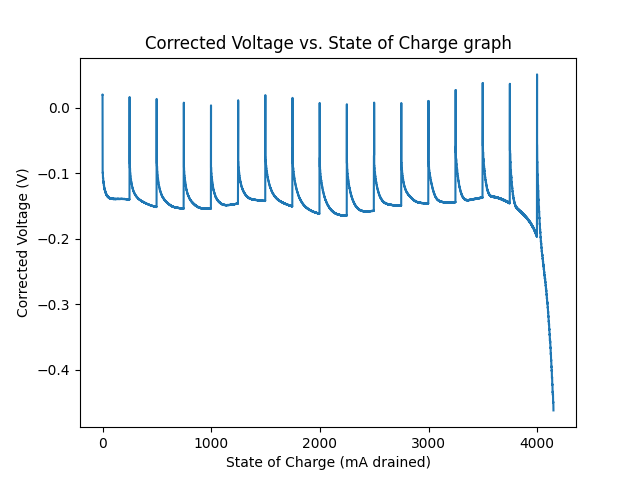

101002


In [4]:
# read data from the csv file for the 10A cell run
transient_data = pd.read_csv("0A90S-10A90S Cell 2 Run 1.csv")
# subtract the values of the 1A constant cell run from the 10A cell run to get the corrected voltage values 
transient_data['SOC_CORRECTED_DMM_VOLTAGE'] = transient_data['DMM_VOLTAGE'] - ocv_fit(transient_data['LOAD_CAPACITY'])
corrected_voltage = transient_data['SOC_CORRECTED_DMM_VOLTAGE'].to_list()
time_stamps = transient_data['TIME_STAMP'].to_list()
soc = transient_data['LOAD_CAPACITY'].to_list()

plt.figure()
plt.plot(time_stamps, corrected_voltage)
plt.title("Corrected Voltage vs. Time graph")
plt.xlabel("Time (s)")
plt.ylabel("Corrected Voltage (V)")
plt.show()

plt.figure()
plt.plot(soc, corrected_voltage)
plt.title("Corrected Voltage vs. State of Charge graph")
plt.xlabel("State of Charge (mA drained)")
plt.ylabel("Corrected Voltage (V)")
plt.show()

print(len(corrected_voltage))

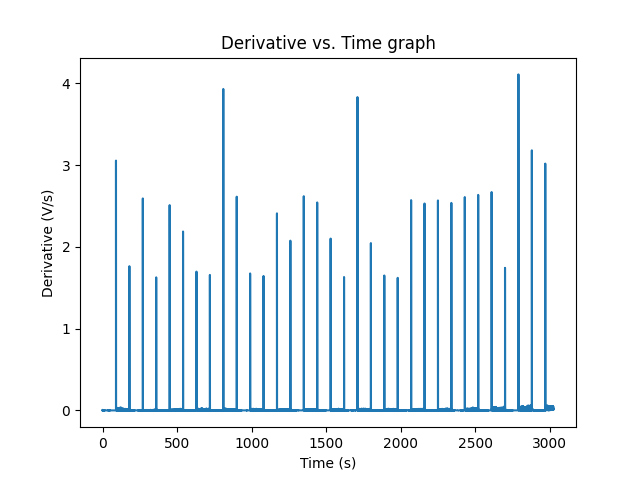

In [5]:
# find voltage drop points by finding the derivatives at every point of the 10A cell run graph 
derivatives = [0]

for i in range(len(transient_data) - 1):
    derivatives.append((corrected_voltage[i + 1] - corrected_voltage[i]) / (time_stamps[i + 1] - time_stamps[i]))

transient_data['SOC_CORRECTED_DMM_VOLTAGE_DER'] = derivatives

# plot the derivatives 
plt.figure()
plt.plot(time_stamps, np.abs(transient_data['SOC_CORRECTED_DMM_VOLTAGE_DER']))
plt.title("Derivative vs. Time graph")
plt.xlabel("Time (s)")
plt.ylabel("Derivative (V/s)")
plt.show()

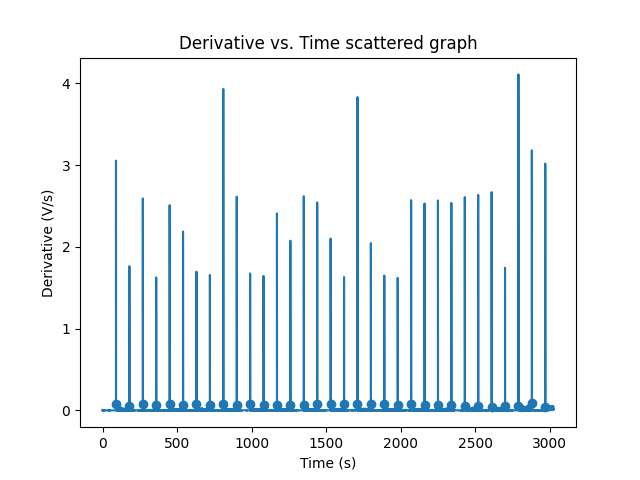

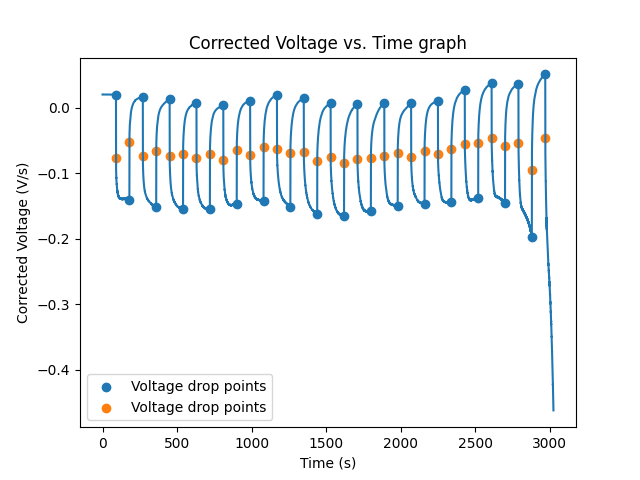

In [7]:
import scipy

# find voltage drop points using the scipy library 
(peaks, properties) = scipy.signal.find_peaks(np.abs(transient_data['SOC_CORRECTED_DMM_VOLTAGE_DER']), height=0.5, threshold=0.5, distance=100, width=1, rel_height=0.7)
volt_list_one = list(transient_data['SOC_CORRECTED_DMM_VOLTAGE'][np.round(properties['left_ips'])])
volt_list_two = list(transient_data['SOC_CORRECTED_DMM_VOLTAGE'][np.round(properties['right_ips'])])

# within the derivatives graph, scatter plot the voltage drop points found using scipy to verify whether the voltage drop points are accurate
plt.figure()
plt.plot(transient_data['TIME_STAMP'], np.abs(transient_data['SOC_CORRECTED_DMM_VOLTAGE_DER']))
plt.scatter(transient_data['TIME_STAMP'][np.round(properties['left_ips'])], np.abs(volt_list_two))
plt.title("Derivative vs. Time scattered graph")
plt.xlabel("Time (s)")
plt.ylabel("Derivative (V/s)")
plt.show()

# within the 10A cell run graph, scatter plot the verfied voltage drop points to visualize the points
plt.figure()
plt.plot(transient_data['TIME_STAMP'], transient_data['SOC_CORRECTED_DMM_VOLTAGE'])
plt.scatter(transient_data['TIME_STAMP'][np.round(properties['left_ips'])], volt_list_one, label="Voltage drop points")
plt.scatter(transient_data['TIME_STAMP'][np.round(properties['right_ips'])], volt_list_two, label="Voltage drop points")
plt.legend(loc="lower left")
plt.title("Corrected Voltage vs. Time graph")
plt.xlabel("Time (s)")
plt.ylabel("Corrected Voltage (V/s)")
plt.show()

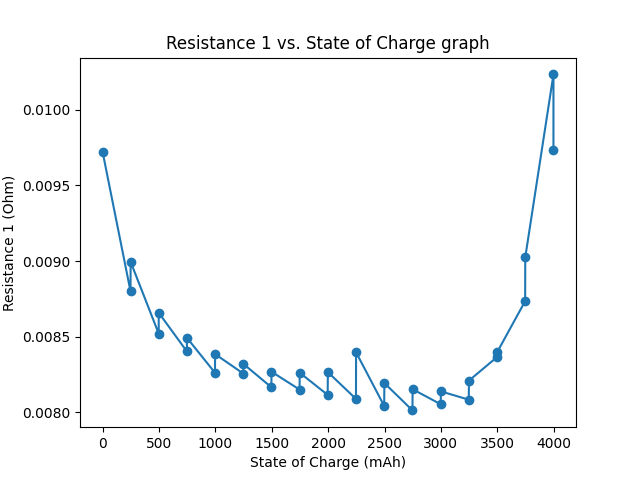

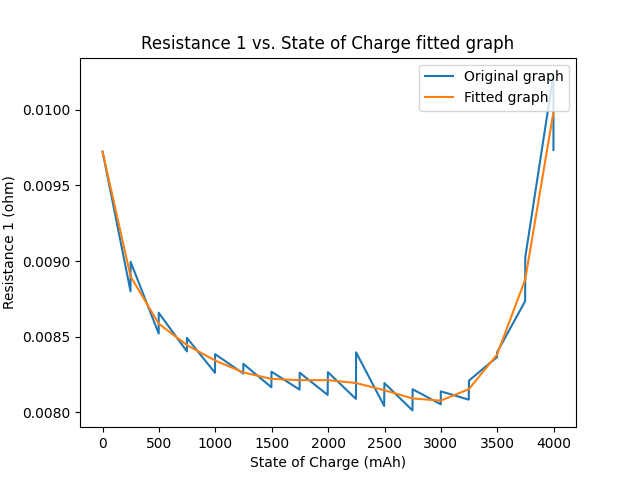

In [8]:
# plot resistance of resistor 1 with respect to soc 
corr_volt_to_index = {v: index for index, v in enumerate(corrected_voltage)}
resistance_one = [abs(v - volt_list_one[i]) / 10 for i, v in enumerate(volt_list_two)]
v_one_drop_soc = [soc[corr_volt_to_index[x]] for i, x in enumerate(volt_list_two)]
plt.figure()
plt.plot(v_one_drop_soc, resistance_one)
plt.scatter(v_one_drop_soc, resistance_one)
plt.title("Resistance 1 vs. State of Charge graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Resistance 1 (Ohm)")
plt.show()

# plot fitted graph of resistor 1 with respect to soc
r_one_fit = np.polynomial.polynomial.Polynomial.fit(v_one_drop_soc, resistance_one, 10)
plt.figure()
plt.plot(v_one_drop_soc, resistance_one, label="Original graph")
plt.plot(v_one_drop_soc, r_one_fit(np.array(v_one_drop_soc)), label="Fitted graph")
plt.legend(loc="upper right")
plt.title("Resistance 1 vs. State of Charge fitted graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Resistance 1 (ohm)")
plt.show()

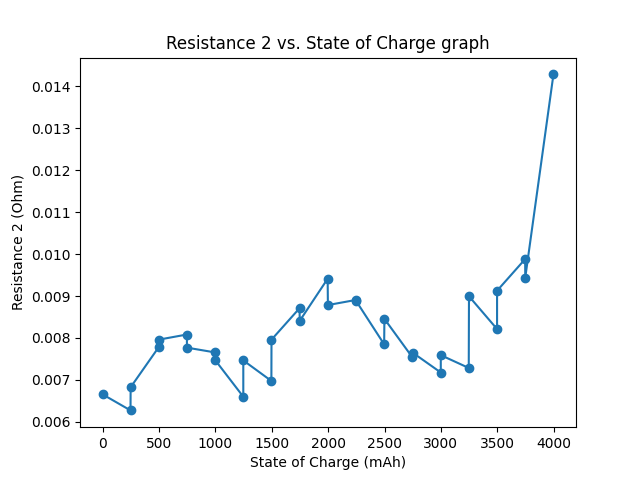

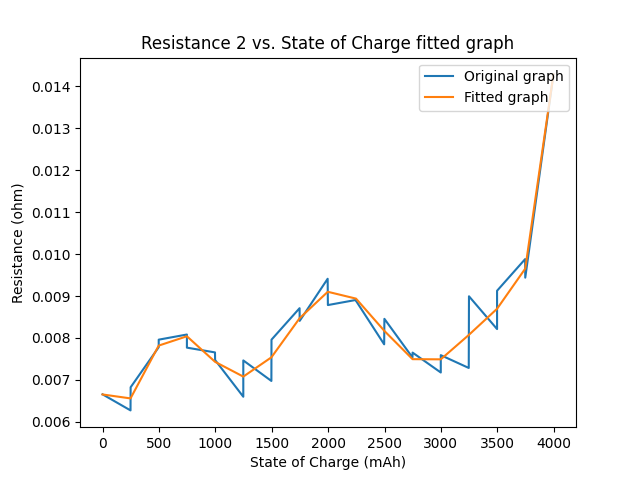

In [9]:
# plot resistance of resistor 2 with respect to soc 
resistance_two = [abs(v - volt_list_two[i - 1]) / 10 for i, v in enumerate(volt_list_one) if i != len(volt_list_two) - 1]
r_two_soc = v_one_drop_soc[:-1]
plt.figure()
plt.plot(r_two_soc, resistance_two)
plt.scatter(r_two_soc, resistance_two)
plt.title("Resistance 2 vs. State of Charge graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Resistance 2 (Ohm)")
plt.show()

# plot fitted graph of resistor 2 with respect to soc
r_two_fit = np.polynomial.polynomial.Polynomial.fit(r_two_soc, resistance_two, 10)
plt.figure()
plt.plot(r_two_soc, resistance_two, label="Original graph")
plt.plot(r_two_soc, r_two_fit(np.array(r_two_soc)), label="Fitted graph")
plt.legend(loc="upper right")
plt.title("Resistance 2 vs. State of Charge fitted graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Resistance (ohm)")
plt.show()

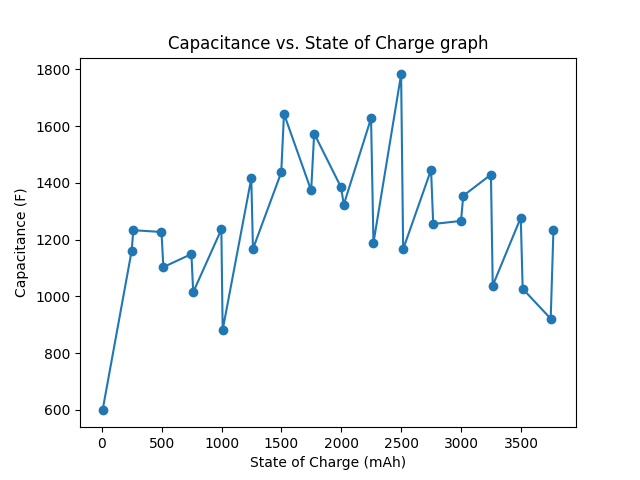

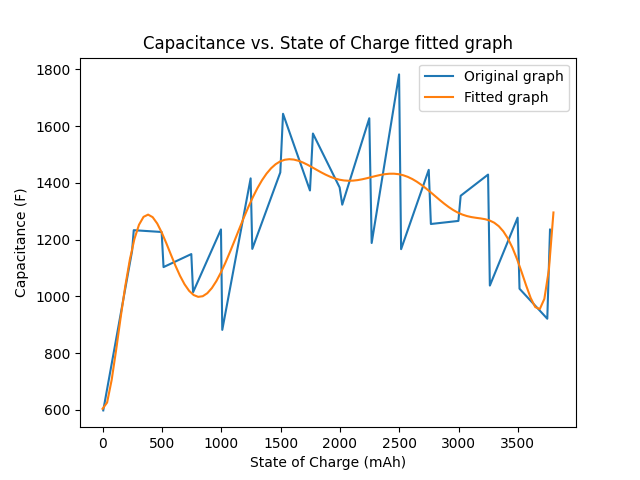

In [10]:
import math

# find the voltages of the half lives
half_life_v = [(volt + volt_list_one[n + 1]) / 2 for n, volt in enumerate(volt_list_two) if n != len(volt_list_two) - 1]
half_life_soc = []
half_lives = []
half_life_voltage = []
capacitance_list = []
new_r_two = []
ln_two = math.log(2)
# find the time for the half lives
for x in range(0, len(half_life_v) - 1):
    if x < len(volt_list_two) - 1:
        # find the index of the voltage before and after it rises/drops
        v_initial_index = corr_volt_to_index[volt_list_two[x]]
        v_final_index = corr_volt_to_index[volt_list_one[x + 1]]
        # compile a new voltage list that goes from the initial to final voltage to shrink the scope of searching through values
        new_v_list = corrected_voltage[v_initial_index:v_final_index]
        # find the closest value in the new voltage list that corresponds to the half life voltage and add it to an updated list of half life voltages
        new_half_life_v = min(new_v_list, key=lambda v:abs(v - half_life_v[x]))
        half_life_voltage.append(new_half_life_v)
        # find the half life time 
        half_life_index = corr_volt_to_index[new_half_life_v]
        half_life = time_stamps[half_life_index] - time_stamps[v_initial_index]
        half_lives.append(half_life)
# find soc corresponding to the half lives
for v in half_life_voltage: 
    h_life_soc = soc[corr_volt_to_index[v]]
    half_life_soc.append(h_life_soc)
# calculate capacitance at each half life
for i, x in enumerate(half_life_soc):
    capacitance = half_lives[i] / (r_two_fit(x) * ln_two)
    new_r_two.append(r_two_fit(x))
    capacitance_list.append(capacitance)
# plot the graph 
plt.figure()
plt.plot(half_life_soc, capacitance_list)
plt.scatter(half_life_soc, capacitance_list)
plt.title("Capacitance vs. State of Charge graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Capacitance (F)")
plt.show()

# plot fitted graph of capacitance with respect to soc
capacitance_fit = np.polynomial.polynomial.Polynomial.fit(half_life_soc, capacitance_list, 10)
plt.figure()
plt.plot(half_life_soc, capacitance_list, label="Original graph")
plt.plot(np.linspace(0, 3800, num=100), capacitance_fit(np.linspace(0, 3800, num=100)), label="Fitted graph")
plt.legend(loc="upper right")
plt.title("Capacitance vs. State of Charge fitted graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Capacitance (F)")
plt.show()

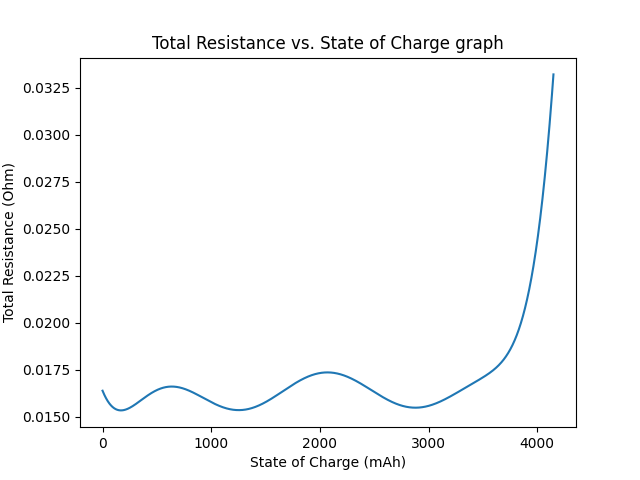

In [11]:
# plot the graph of total resistance vs. soc by adding the fitted graphs of resistance one and two
total_resistance = [r_one_fit(i) + r_two_fit(i) for i in soc]
plt.figure()
plt.plot(soc, total_resistance)
plt.title("Total Resistance vs. State of Charge graph")
plt.xlabel("State of Charge (mAh)")
plt.ylabel("Total Resistance (Ohm)")
plt.show()

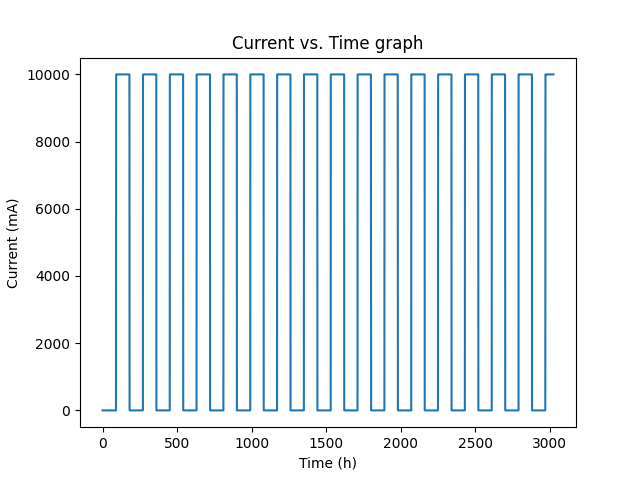

In [12]:
# replicate the ocv voltage graph
current = transient_data["LOAD_CURRENT"].to_list()
mili_amp = [i * 1000 for i in current]
plt.figure()
plt.plot(time_stamps, mili_amp)
plt.title("Current vs. Time graph")
plt.xlabel("Time (h)")
plt.ylabel("Current (mA)")
plt.show()

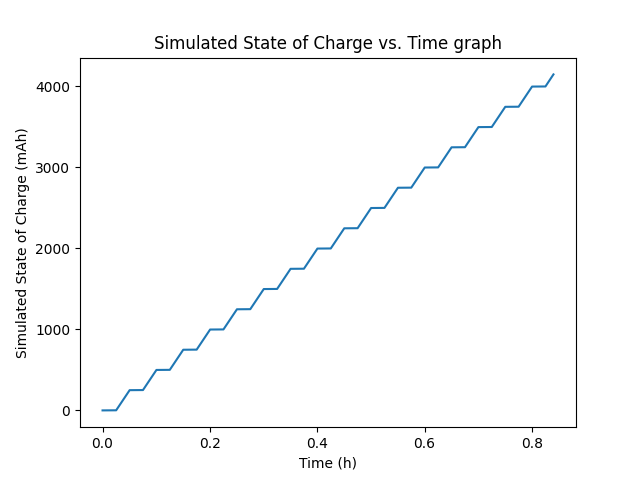

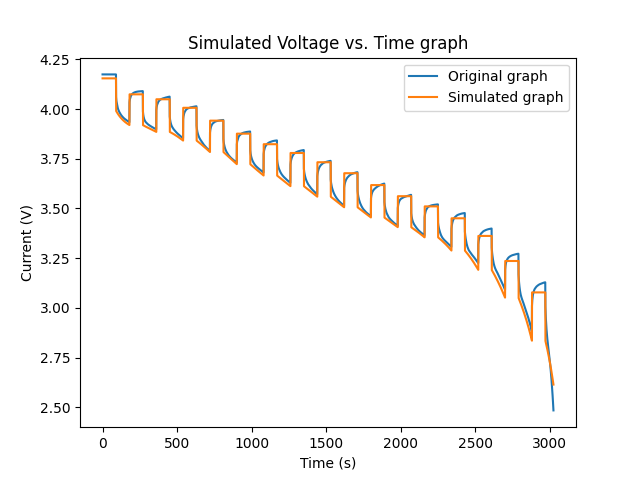

In [13]:
# find the integral of the current vs. time graph to compile a simulated list for state of charge
simulated_soc = []
simulated_ocv = []
integral = 0
time_sec = [t / 3600 for t in time_stamps]
soc_to_index = {s: i for i, s in enumerate(soc)}
for index, m_amp in enumerate(mili_amp): 
    if index != 0:
        delta_x = time_sec[index] - time_sec[index - 1]
        integral += delta_x * m_amp 
        simulated_soc.append(integral)

plt.figure()
plt.title("Simulated State of Charge vs. Time graph")
plt.plot(time_sec[1:], simulated_soc)
plt.xlabel("Time (h)")
plt.ylabel("Simulated State of Charge (mAh)")
plt.show()

# use the simulated list of state of charge to find the corresponding open circuit voltages based on the csv file 
simulated_voltage_drop = []
sim_original_voltage = []

for i, x in enumerate(simulated_soc): 
    if i != 0:
        simulated_resistance = r_one_fit(x) + r_two_fit(x)
        simulated_voltage_drop = current[i] * simulated_resistance
        simulated_original_voltage = ocv_fit(x) - simulated_voltage_drop
        sim_original_voltage.append(simulated_original_voltage)

plt.figure()
plt.title("Simulated Voltage vs. Time graph")
plt.plot(time_stamps, transient_data['DMM_VOLTAGE'], label="Original graph")
plt.plot(time_stamps[2:], sim_original_voltage, label="Simulated graph")
plt.xlabel("Time (s)")
plt.ylabel("Current (V)")
plt.legend(loc="upper right")
plt.show()

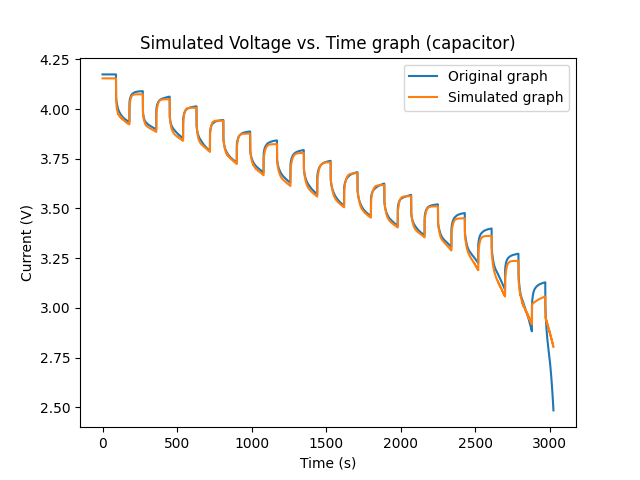

In [17]:
# conduct simulation with the capacitor to reproduce a graph showing the potential difference after voltage runs through both resistors
sim_voltage = []
charge = 0
for i, t in enumerate(time_stamps): 
    if i != len(time_stamps) - 1:
        e_current = current[i]
        e_soc = soc[i]
        capacitance = capacitance_fit(e_soc)
        r1 = r_one_fit(e_soc)
        r2 = r_two_fit(e_soc)
        voltage_rc = charge / capacitance
        voltage_r1 = e_current * r1
        voltage_ocv = ocv_fit(e_soc)
        current_r2 = voltage_rc / r2
        current_c = e_current - current_r2
        delta_charge = current_c * (time_stamps[i + 1] - time_stamps[i])
        charge += delta_charge
        updated_rc_voltage = charge / capacitance_fit(soc[i + 1])
        sim_voltage.append(voltage_ocv - updated_rc_voltage - voltage_r1)
plt.figure()
plt.title("Simulated Voltage vs. Time graph (capacitor)")
plt.plot(time_stamps, transient_data['DMM_VOLTAGE'], label="Original graph")
plt.plot(time_stamps[:-1], sim_voltage, label="Simulated graph")
plt.xlabel("Time (s)")
plt.ylabel("Current (V)")
plt.legend(loc="upper right")
plt.show()